# Shelton–Alcaraz publication figures

This optional notebook recreates the three game-theory figures from the tables exported by `SheltonAlcaraz.ipynb`. It does not repeat the data preparation or statistical analysis.

Run the main notebook first. This notebook additionally requires XeLaTeX and the CMU Sans Serif TTF files (`cmunss.ttf`, `cmunsi.ttf`, `cmunsx.ttf`, and `cmunso.ttf`). It writes polished PDF and PNG files to `publication_figures/`.

In [1]:
from pathlib import Path
import shutil

import matplotlib
matplotlib.use("pgf")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
from IPython.display import Image, display

INPUT_DIR = Path("notebook_outputs")
OUTPUT_DIR = Path("publication_figures")
OUTPUT_DIR.mkdir(exist_ok=True)

## Publication typography

XeLaTeX typesets every label. `fontspec` loads the actual CMU Sans Serif files, including their bold and oblique variants. Change `CMU_FONT_DIR` if the fonts are installed elsewhere.

In [2]:
CMU_FONT_DIR = Path.home() / "Library" / "Fonts"
font_files = {
    "UprightFont": "cmunss.ttf",
    "ItalicFont": "cmunsi.ttf",
    "BoldFont": "cmunsx.ttf",
    "BoldItalicFont": "cmunso.ttf",
}
assert shutil.which("xelatex"), "XeLaTeX is required for the publication figures."
missing_fonts = [name for name in font_files.values() if not (CMU_FONT_DIR / name).is_file()]
assert not missing_fonts, f"Missing CMU Sans Serif files: {missing_fonts}"

font_options = ",\n".join(f"{option}={filename}" for option, filename in font_files.items())
latex_preamble = (
    r"\usepackage{fontspec}" + "\n"
    + "\\setsansfont[\nPath=" + CMU_FONT_DIR.as_posix() + "/,\n"
    + font_options + "\n]{CMU Sans Serif}\n"
    + r"\renewcommand{\familydefault}{\sfdefault}"
)
plt.rcParams.update({
    "pgf.texsystem": "xelatex",
    "pgf.rcfonts": False,
    "pgf.preamble": latex_preamble,
    "font.family": "sans-serif",
    "axes.unicode_minus": False,
})

## Load the exported game inputs

In [3]:
required_files = ["shelton_payoffs.csv", "alcaraz_payoffs.csv",
                  "shelton_counts.csv", "alcaraz_counts.csv"]
missing_inputs = [name for name in required_files if not (INPUT_DIR / name).is_file()]
assert not missing_inputs, ("Run SheltonAlcaraz.ipynb first. Missing exports: "
                            + ", ".join(missing_inputs))

shelton_payoffs = pd.read_csv(INPUT_DIR / "shelton_payoffs.csv", index_col=0)
alcaraz_payoffs = pd.read_csv(INPUT_DIR / "alcaraz_payoffs.csv", index_col=0)
shelton_counts = pd.read_csv(INPUT_DIR / "shelton_counts.csv", index_col=0)
alcaraz_counts = pd.read_csv(INPUT_DIR / "alcaraz_counts.csv", index_col=0)
row_labels = shelton_payoffs.index.tolist()
column_labels = shelton_payoffs.columns.tolist()
A = shelton_payoffs.to_numpy(dtype=float)
B = alcaraz_payoffs.reindex(index=row_labels, columns=column_labels).to_numpy(dtype=float)
assert A.shape == B.shape == (2, 2) and np.isfinite(A).all() and np.isfinite(B).all()

In [4]:
def save_and_display(fig, name):
    pdf = OUTPUT_DIR / f"{name}.pdf"
    png = OUTPUT_DIR / f"{name}.png"
    fig.savefig(pdf, bbox_inches="tight")
    fig.savefig(png, bbox_inches="tight", dpi=240)
    plt.close(fig)
    display(Image(filename=str(png), width=600))

## Payoff matrices

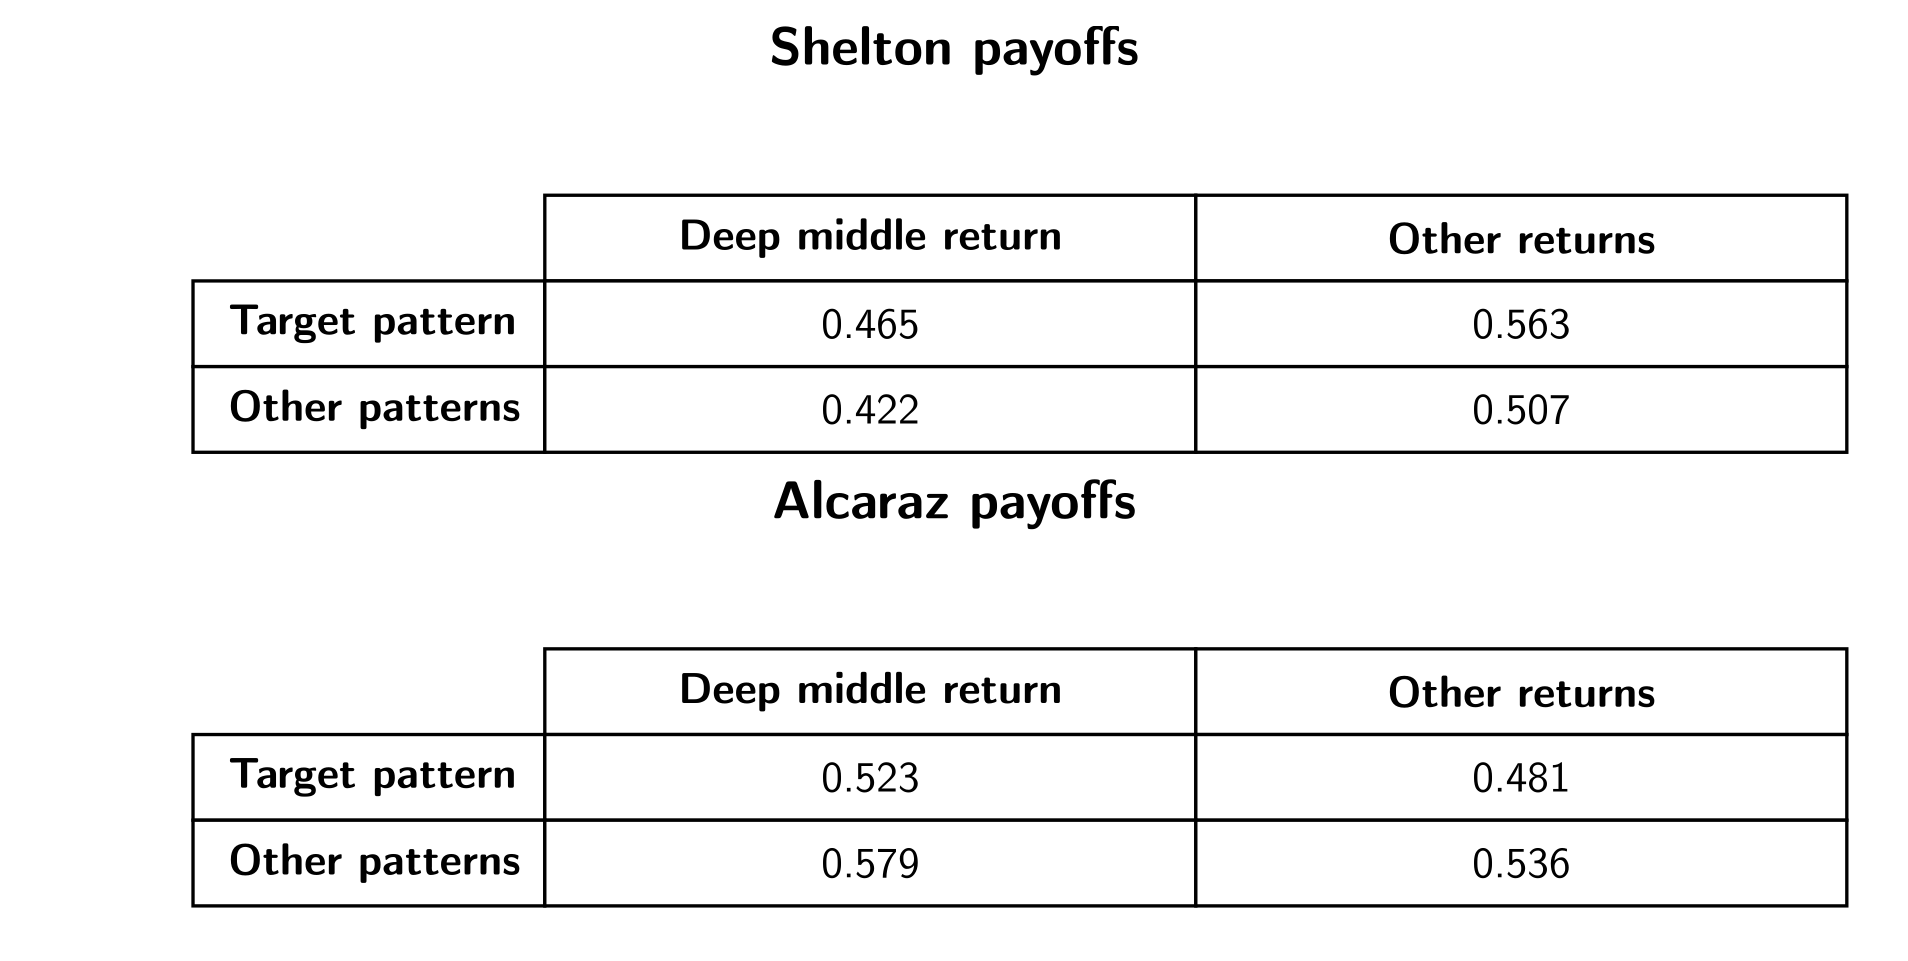

In [5]:
matrix_fig, axes = plt.subplots(2, 1, figsize=(10, 4.5))
for ax, matrix, player in zip(axes, [A, B], ["Shelton", "Alcaraz"]):
    ax.axis("off")
    ax.set_title(player + " payoffs", fontsize=16, fontweight="bold", pad=12)
    table = ax.table(cellText=[[f"{value:.3f}" for value in row] for row in matrix],
                     rowLabels=row_labels, colLabels=column_labels,
                     cellLoc="center", bbox=[.28, .08, .7, .68])
    table.auto_set_font_size(False)
    table.set_fontsize(13)
    for (row, column), cell in table.get_celld().items():
        cell.set_text_props(weight="bold" if row == 0 or column == -1 else "normal")
save_and_display(matrix_fig, "payoff_matrices")

## Replicator phase portrait

The tagged release is installed from pynamo's official repository.

In [6]:
%pip install --quiet --force-reinstall --no-deps "pynamo-egt @ git+https://github.com/SlimaneD/pynamo.git@v0.2.0"

import pynamo_egt as pn

B_for_pynamo = B.T

Note: you may need to restart the kernel to use updated packages.


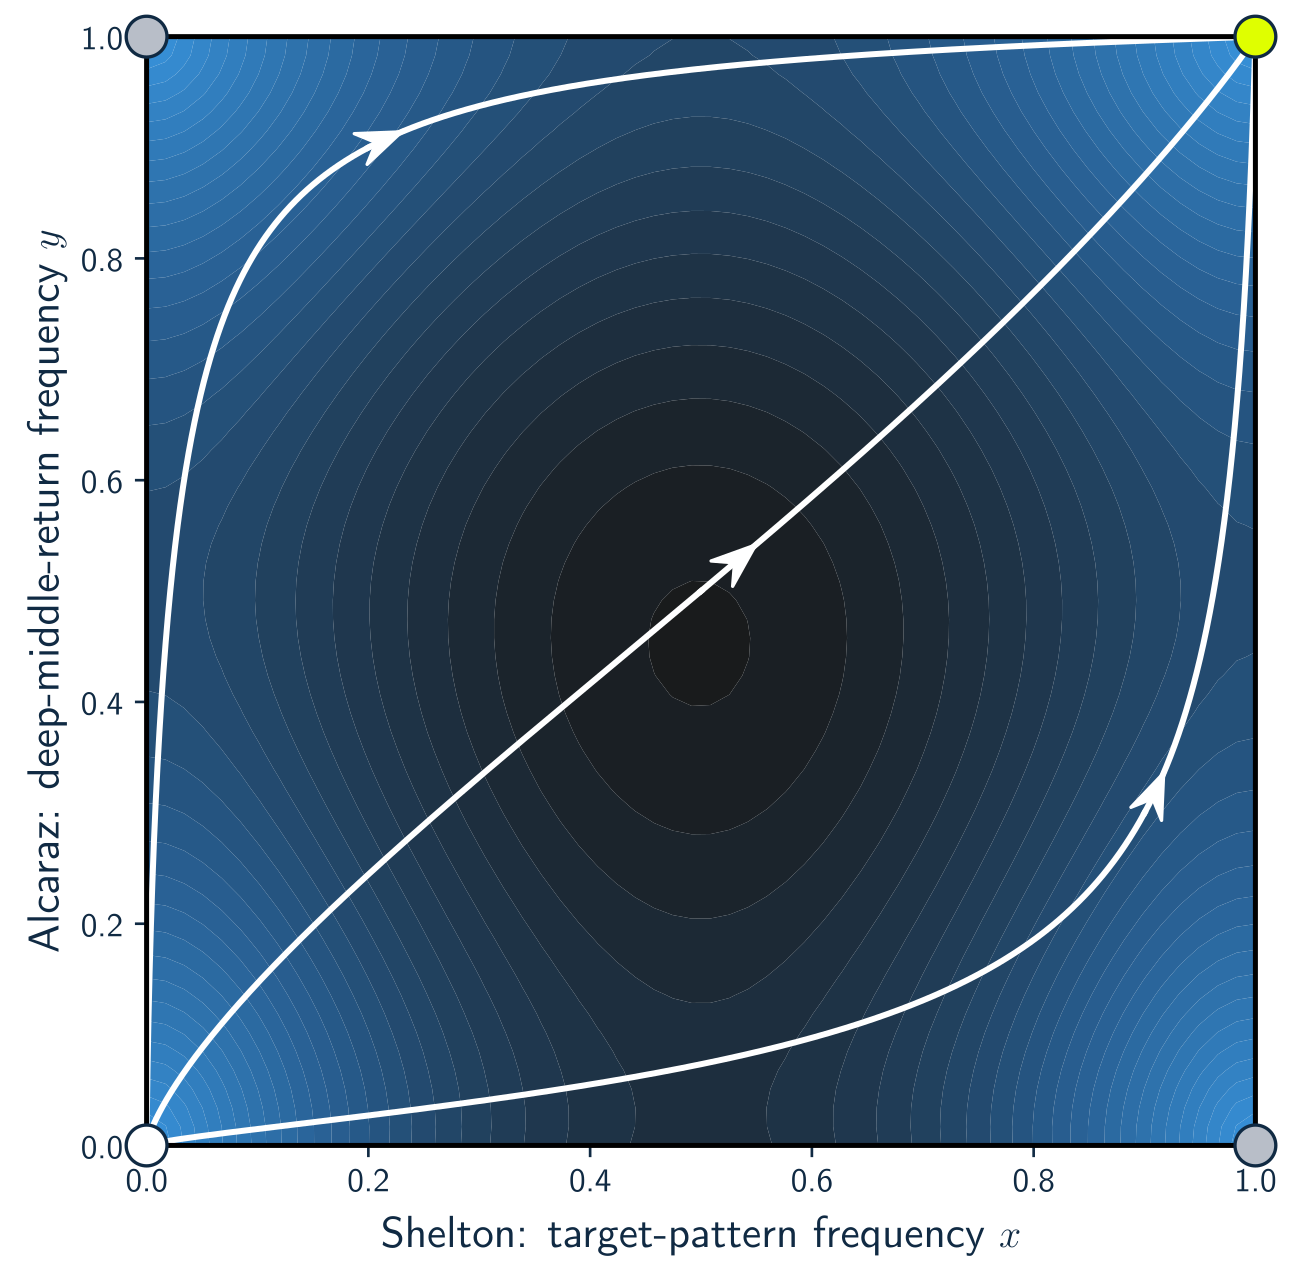

In [7]:
navy, tennis_yellow, light_gray = "#102A43", "#DFFF00", "#B8BEC8"
tennis_blues = LinearSegmentedColormap.from_list("blue_to_black",
                                                   ["#2389DA", "#104A80", "#000000"])
game = pn.Game(
    name="Shelton--Alcaraz: exploratory adaptation model",
    payoffs=(A, B_for_pynamo), player_strategy_labels=[row_labels, column_labels],
    player_labels=["Shelton", "Alcaraz"], symmetric=False,
)
phase_fig, phase_ax = pn.phase_portrait(
    game, starts=[[.2, .9], [.9, .3], [.5, .5]], tmax=200,
    show_speed=True, speed_cmap=tennis_blues, speed_levels=30,
    trajectory_color="white", trajectory_linewidth=1.8,
    sink_color=tennis_yellow, saddle_color=light_gray, source_color="white",
    center_color=light_gray, equilibrium_edgecolor=navy, equilibrium_size=150,
)
phase_ax.set_xlabel(r"Shelton: Wide + opposite frequency $x$", color=navy)
phase_ax.set_ylabel(r"Alcaraz: deep-middle-return frequency $y$", color=navy)
phase_ax.set_title("")
phase_ax.tick_params(colors=navy)
for spine in phase_ax.spines.values():
    spine.set_color(navy)
phase_fig.patch.set_facecolor("white")
save_and_display(phase_fig, "shelton_alcaraz_phase_portrait")

## Payoff-difference map

In [8]:
def expected_payoff(matrix, x, y):
    return (x*y*matrix[0, 0] + x*(1-y)*matrix[0, 1]
            + (1-x)*y*matrix[1, 0] + (1-x)*(1-y)*matrix[1, 1])

grid = np.linspace(0, 1, 301)
X, Y = np.meshgrid(grid, grid)
difference = expected_payoff(A, X, Y) - expected_payoff(B, X, Y)
limit = max(float(np.abs(difference).max()), 1e-6)
norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

x_count = int(shelton_counts.loc["Wide + opposite"].sum())
x_total = int(shelton_counts.to_numpy().sum())
y_count = int(alcaraz_counts["Deep middle return"].sum())
y_total = int(alcaraz_counts.to_numpy().sum())
x_historical, y_historical = x_count / x_total, y_count / y_total
n_deep_middle = int(alcaraz_counts.loc["Wide + opposite", "Deep middle return"])
n_total = int(alcaraz_counts.loc["Wide + opposite"].sum())
x_observed, y_observed = 1.0, n_deep_middle / n_total

In [9]:
def draw_score_boundary(ax):
    if difference.min() < 0 < difference.max():
        contour = ax.contour(X, Y, difference, levels=[0], colors="black", linewidths=1.5)
        ax.clabel(contour, fmt={0: "Equal performance scores"}, fontsize=11, manual=[(.6, .4)])
    if np.all(A[0] > A[1]) and np.all(B[:, 0] > B[:, 1]):
        ax.scatter([1], [1], s=110, color="black", clip_on=False, zorder=5)
        ax.annotate("Stable equilibrium", xy=(1, 1), xytext=(-15, -25),
                    textcoords="offset points", ha="right")

def draw_reference_points(ax):
    ax.scatter(x_observed, y_observed, s=160, facecolor="gold", edgecolor="black",
               linewidth=1.5, clip_on=False, zorder=10)
    ax.annotate("100% Wide + opposite scenario\n" + rf"$y={y_observed:.3f}$"
                + f" ({n_deep_middle}/{n_total} points)", xy=(x_observed, y_observed),
                xytext=(-20, 25), textcoords="offset points", ha="right", va="bottom",
                arrowprops=dict(arrowstyle="->", color="black"),
                bbox=dict(facecolor="white", alpha=.9, edgecolor="gray"), zorder=11)
    ax.scatter(x_historical, y_historical, s=110, facecolor="#9CA3AF",
               edgecolor="#111827", linewidth=1.3, zorder=12)
    ax.annotate("Historical frequencies\n" + rf"$x$ ({x_count}/{x_total})" + "\n"
                + rf"$y$ ({y_count}/{y_total})", xy=(x_historical, y_historical),
                xytext=(20, 25), textcoords="offset points", ha="left", va="bottom",
                arrowprops=dict(arrowstyle="->", color="black"),
                bbox=dict(facecolor="white", alpha=.9, edgecolor="gray"), zorder=12)

def draw_scenario_arrow(ax):
    movement = ax.annotate("", xy=(x_observed, y_observed),
        xytext=(x_historical, y_historical),
        arrowprops=dict(arrowstyle="-|>", color="olivedrab", lw=2.5,
                        mutation_scale=20, shrinkA=9, shrinkB=10), zorder=8)
    movement.arrow_patch.set_path_effects([
        pe.Stroke(linewidth=4, foreground=navy), pe.Normal(),
    ])
    ax.annotate("More Wide + opposite use",
        xy=((x_historical+x_observed)/2, (y_historical+y_observed)/2),
        xytext=(0, -18), textcoords="offset points", ha="center", va="bottom",
        fontsize=11, color=navy,
        bbox=dict(facecolor="white", edgecolor="none", alpha=.9, pad=3), zorder=9)

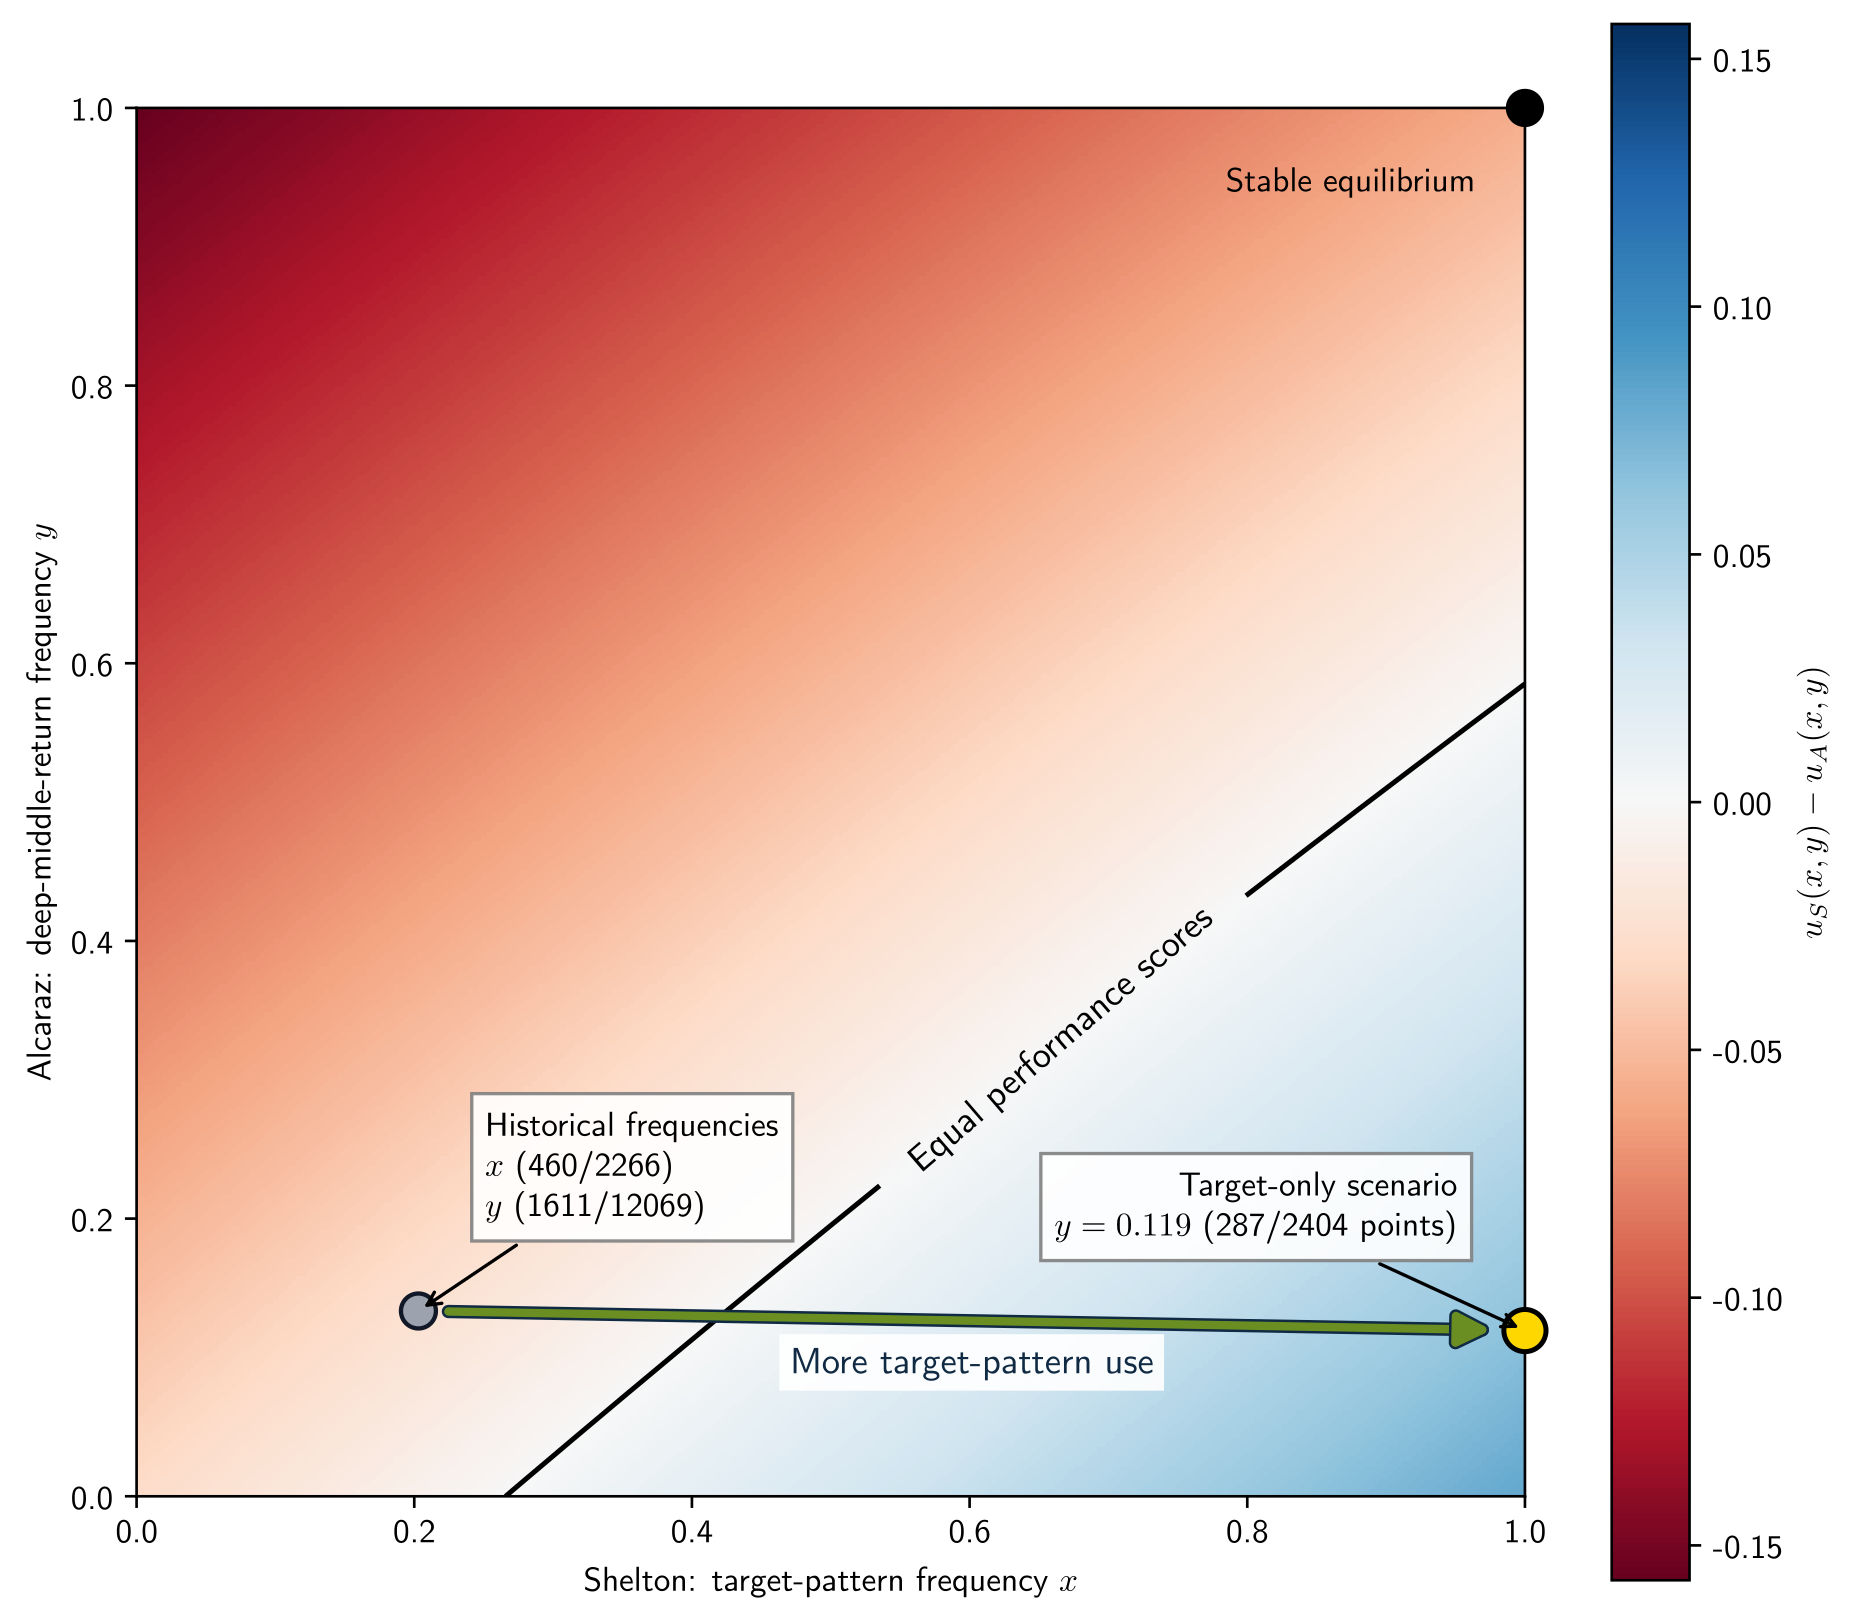

In [10]:
difference_fig, difference_ax = plt.subplots(figsize=(8, 7))
heatmap = difference_ax.pcolormesh(X, Y, difference, shading="auto", cmap="RdBu",
                                    norm=norm, rasterized=True)
colorbar = difference_fig.colorbar(heatmap, ax=difference_ax)
colorbar.set_label(r"$u_S(x,y)-u_A(x,y)$")
draw_score_boundary(difference_ax)
draw_reference_points(difference_ax)
draw_scenario_arrow(difference_ax)
difference_ax.set(xlabel=r"Shelton: Wide + opposite frequency $x$",
                  ylabel=r"Alcaraz: deep-middle-return frequency $y$",
                  xlim=(0, 1), ylim=(0, 1))
difference_ax.set_aspect("equal")
difference_fig.tight_layout()
save_and_display(difference_fig, "shelton_alcaraz_payoff_difference")